In [7]:
!python3 -m pip install -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [8]:
%load_ext autoreload
%autoreload 2

# Setup notebook environment

import pandas as pd
import geopandas as gpd
import sys
import os

if os.path.abspath('.') not in sys.path:
    sys.path.append(os.path.abspath('.'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The below cell processes and generates data used for analysis. Uncomment the function call to enable data generation (not required unless data needs to be regenerated).

In [9]:
%%capture
# Suppress debug output (comment above line to show debug output)

# Generate data linking collisions, pavement condition, and traffic volumes
from src.pavement_collisions_traffic.generate_data import generate_data

# generate_data() 
# Uncomment above function to run data generation

In [10]:
# Import analysis scripts
from src.pavement_collisions_traffic.analysis_no_traffic import analyze_pavement_safety
from src.pavement_collisions_traffic.analysis_with_traffic import analyze_pavement_safety_vmt
from src.pavement_collisions_traffic.compare_analysis_methods import compare_analysis_methods

from src.pavement_collisions_traffic.interactive_map import generate_map_for_year

# Load csv file
segments_collisions_pci_counts = pd.read_csv('./data/processed/segments_collisions_pci_counts.csv')

# Load geojson files
roads_geo = gpd.read_file('./data/raw/streets_repair_line_segments/sd_paving_segs_datasd.geojson')
zoning_geo = gpd.read_file('./data/raw/zoning/zoning_datasd.geojson')

The below function analyzes pavement condition and collisions, not accounting for traffic volumes.

In the visualization, we can see that the four lane collector street and the 6 lane arterial street have noticeably more collisions (with higher severity) per mile as the pavement condition decreases.

However, in this analysis, the volume of traffic (confounding variable) is not accounted for. It could just be that streets with worse pavement condition also have higher traffic volumes, leading to more collisions.

Information about the different street "classes" or "types" is available [here](https://www.sandiego.gov/sites/default/files/2024-12/sdmu-ch2.pdf).

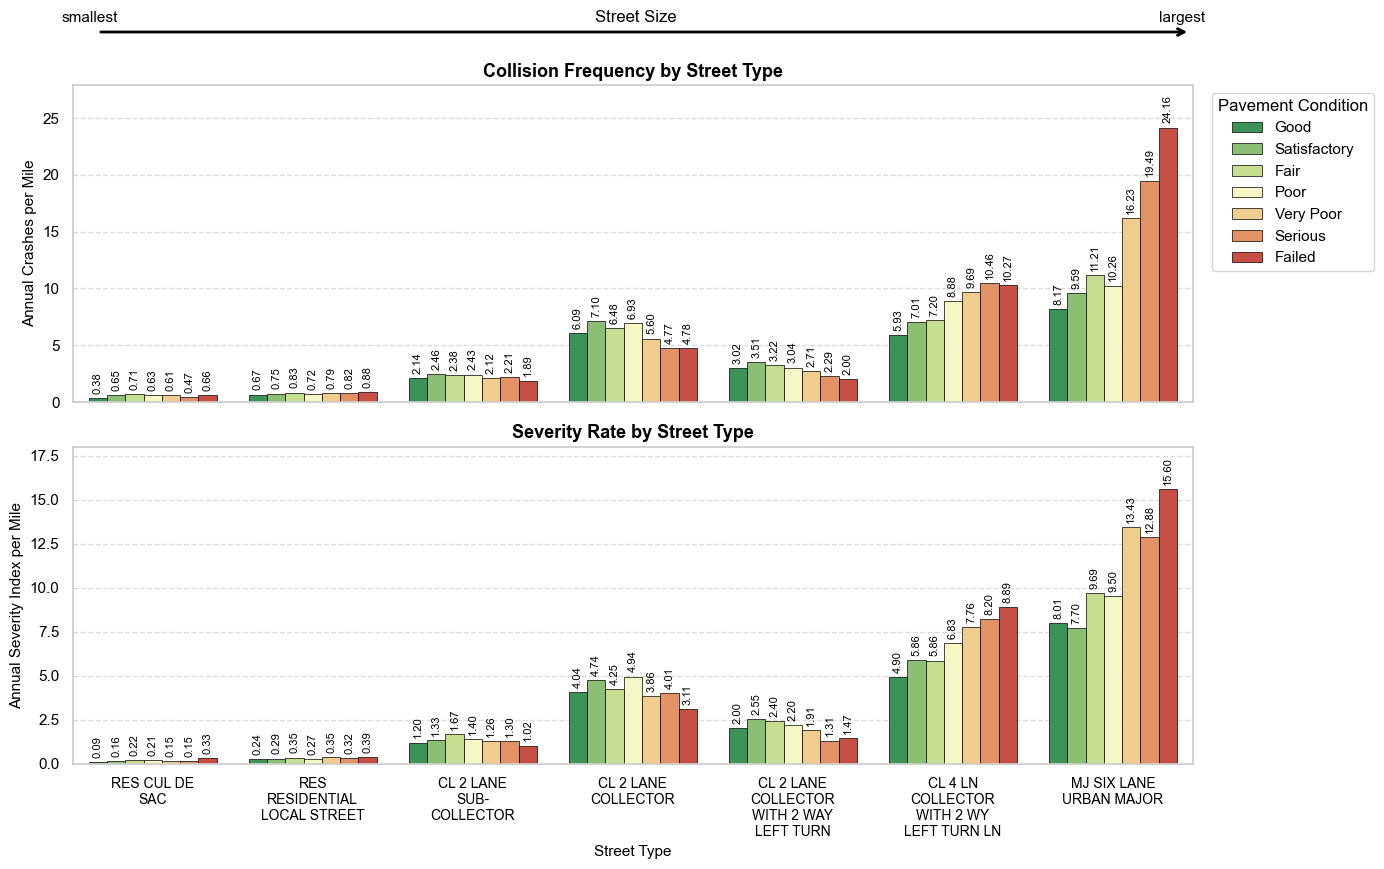

In [11]:
analyze_pavement_safety(segments_collisions_pci_counts) # (from Evan's analysis in src\pavement_collisions_traffic\analysis_no_traffic.py)

In an attempt to control for traffic volumes, the below script calculates the same statistics per million vehicle miles traveled (VMT). However, this analysis should be interpreted with **caution**, as there is **very limited** traffic volume data.

However, even with this limited data, there is still a noticeable trend of more crashes per million VMT for the six lane urban arterial street type as pavement condition worsens.

This could point to a real relationship between pavement condition and traffic safety, specifically for large arterial streets.

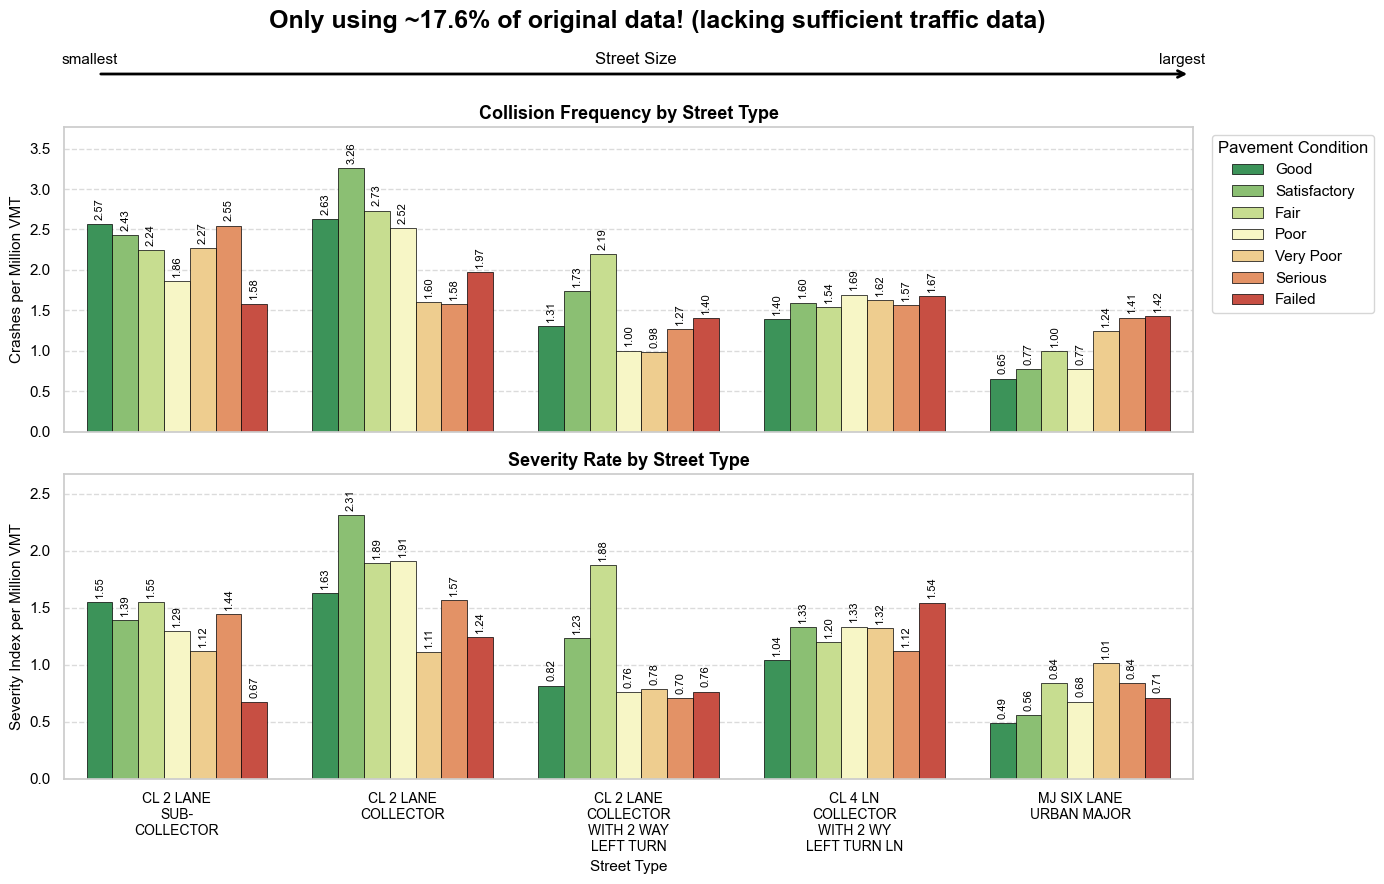

In [12]:
analyze_pavement_safety_vmt(segments_collisions_pci_counts) # (from Evan's analysis in src\pavement_collisions_traffic\analysis_with_traffic.py)

Now, we compare the two analyses (with and without traffic volume control) for the two largest street types. This allows us to see how the limited traffic volume data affects the analysis. 

The graphs display the percent difference from the average to accent the trends.

In conclusion, the most promising finding is that for six lane urban arterial streets, there appears to be a trend of more collisions (both raw and per million VMT) as pavement condition worsens. This points to a meaningful relationship between pavement condition and traffic safety for this street type.

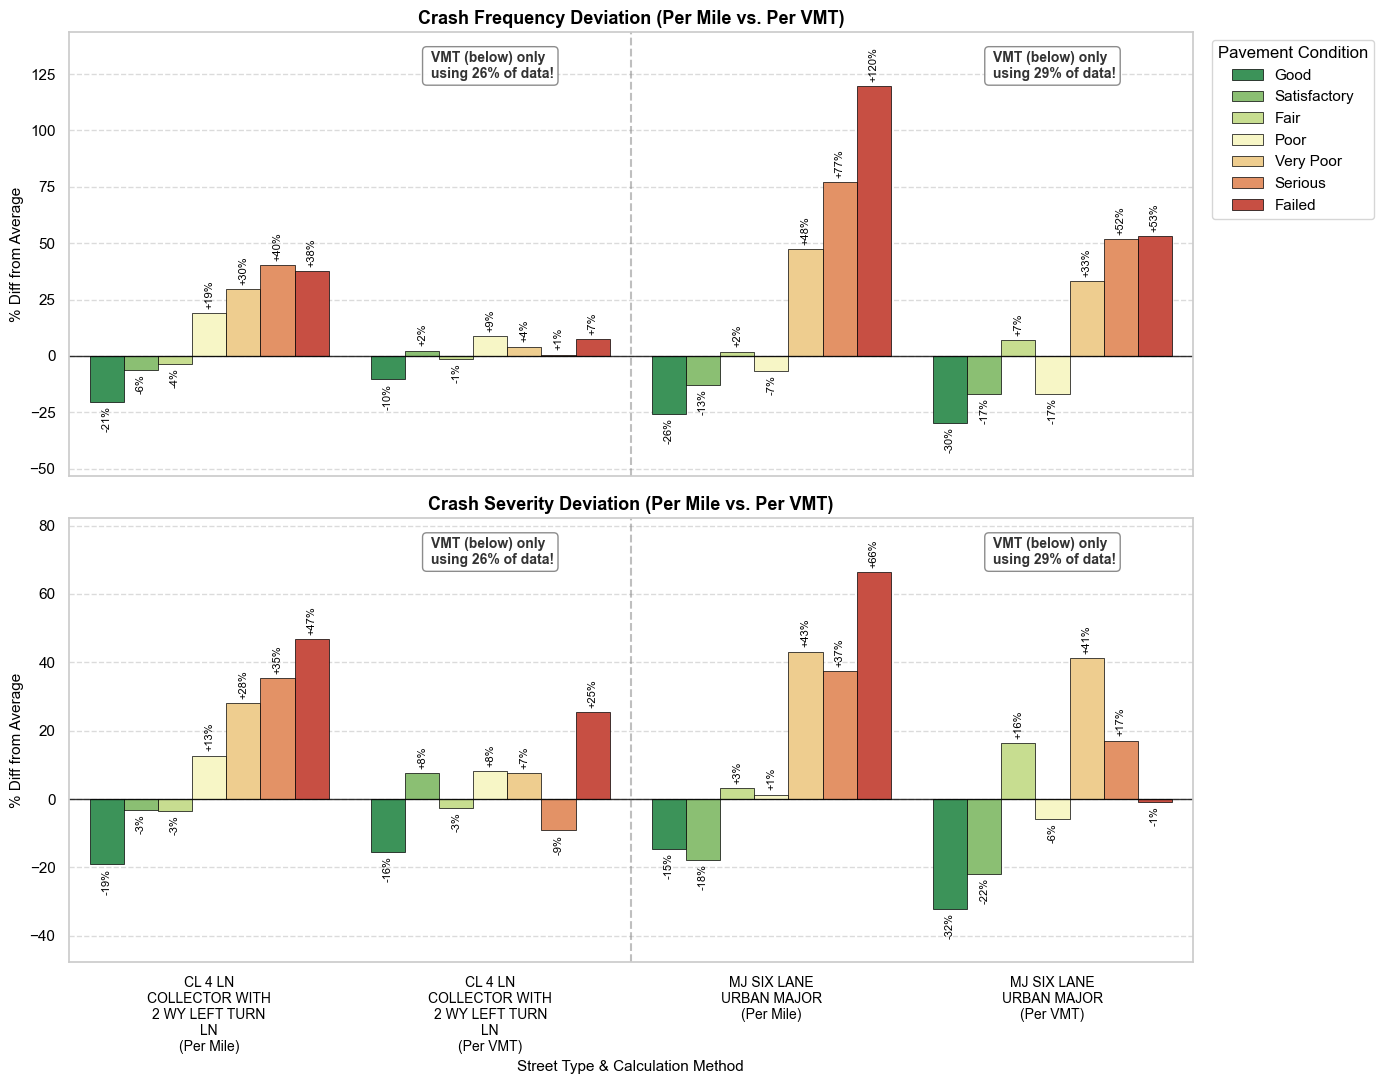

In [13]:
compare_analysis_methods(segments_collisions_pci_counts) # (from Evan's analysis in src\pavement_collisions_traffic\compare_analysis_methods.py)

Now that we have addressed the main question, we can generate an interactive map to visualize the data spatially. 

This function generates an interactive map incorporating pavement conditions, collisions data, and zoning information for a specified year. (All years at once is not possible due to RAM/performance limitations.)

PCI is color coded for easy viewing (same colors in previous visualizations), and **street width/thickness corresponds to to the number of crashes** (thicker lines = more crashes). **Hovering over a zone or street segment provides additional information in a tooltip.**

**Troubleshooting**:

If the map background is missing OR "Make this Notebook Trusted to load map: File -> Trust Notebook" is displayed, try the following:
- Reload the vscode window (command palette -> Reload Window)
- Run the below cell again, **without** regenerating the data prior! (may need to re-run all cells **except** the data generation cell)

Attempting some combination of the above steps should resolve any problems (may need to try a couple times).

In [14]:
# This is the year to generate the map for
YEAR = 2023

if YEAR < 2016 or YEAR > 2025:
    raise ValueError("YEAR must be between 2016 and 2025")

generate_map_for_year(segments_collisions_pci_counts, roads_geo, zoning_geo, YEAR) # (from Evan's analysis in src\pavement_collisions_traffic\interactive_map.py)

TypeError: Object of type Timestamp is not JSON serializable

## Geographic Hotspot Analysis

The following analysis identifies geographic clusters of high collision density and poor pavement conditions using spatial clustering (DBSCAN) and hotspot detection (Getis-Ord Gi*).

This helps identify neighborhoods/areas needing priority attention and supports targeted intervention strategies.


In [ ]:
from src.geographic_analysis.hotspot_detection import geographic_hotspot_analysis

# Run analysis (loads existing if available, or calculates fresh) and display plots
figure, hotspot_summary = geographic_hotspot_analysis()

## Street Repair Projects Evaluation

This analysis evaluates the effectiveness of street repair projects by analyzing:
- PCI improvement before/after repairs
- Repair effectiveness by type (SLURRY, OVERLAY, CONCRETE)
- Collision reduction after repairs
- Repair longevity (time until PCI degrades significantly)

This complements the pavement-collision-traffic analysis by focusing specifically on whether repairs are achieving their intended goals.


In [ ]:
from src.repair_projects_evaluation.repair_effectiveness_analysis import repair_evaluation

# Run analysis (loads existing if available, or calculates fresh) and display plots
df_repairs, df_types, df_collision, df_longevity = repair_evaluation()

### Repair Analysis Summary

Key findings from the repair effectiveness analysis:

- **Overall Effectiveness**: Only 24.8% of repairs show significant PCI improvement (≥10 points)
- **Repair Type Comparison**:
  - **OVERLAY repairs** are most effective (73% effective rate, 24.85 avg improvement)
  - **CONCRETE repairs** are also effective (62% effective rate)
  - **SLURRY repairs** show minimal improvement (only 12% effective, despite being 79% of all repairs)
- **Repair Longevity**: Average PCI degradation per year is -0.84 points, with estimated 20+ years until significant degradation

For more details, see the analysis summary in `src/repair_projects_evaluation/ANALYSIS_SUMMARY.md`


## Collisions Analysis by Zoning Districts

This analysis examines traffic collisions through the lens of urban zoning districts. By linking collision data to specific zoning types (such as residential, commercial, industrial, and so on), we can answer important questions about how land use patterns relate to traffic safety.

**Research Question**: How do traffic collision patterns vary across different zoning districts in San Diego? Which zone types experience the highest collision rates, injuries, and fatalities?

This analysis helps city planners:
- Identify high-risk zones that may need targeted safety interventions
- Understand how land use patterns (residential vs. commercial vs. industrial) correlate with traffic safety


### Data Merging Process

The analysis involves linking each collision report and a specific road segment as shown above, spatially joining segments to zones using geometric intersection info obtained from `.geojson` files and processed using the geopandas API, and aggregating collision metrics per zone. This allows us to analyze collision patterns at the zoning district level, providing insights into how urban planning and land use relate to traffic safety. Below, we first load in the CSV data from `./data/processed/collisions_analysis_with_zoning.csv`, which contains the merged dataframe containing collision details per zone in San Diego.


In [ ]:
# Import the collisions in zones analysis module
from src.collisions_in_zones import (
    load_and_filter_data,
    load_zoning_data,
    load_paving_geometries,
    match_intersections,
    match_segments,
    consolidate_matches,
    join_segments_to_zoning,
    create_zoning_collision_analysis
)

# Check if analysis output exists, if not run the analysis
output_data_path = './data/processed/collisions_analysis_with_zoning.csv'

if not os.path.exists(output_data_path):
    print("Running collisions in zones analysis...")
    print("This may take a few minutes...")
    
    # Run the analysis pipeline
    df_paving, df_coll = load_and_filter_data()
    matches_int = match_intersections(df_paving, df_coll)
    matches_seg = match_segments(df_paving, df_coll)
    all_matches = consolidate_matches(df_coll, matches_int, matches_seg)
    
    gdf_zoning = load_zoning_data()
    gdf_paving_geom = load_paving_geometries()
    
    if gdf_zoning is not None and gdf_paving_geom is not None:
        segment_zoning = join_segments_to_zoning(gdf_paving_geom, gdf_zoning)
        zone_analysis = create_zoning_collision_analysis(df_coll, all_matches, segment_zoning, gdf_zoning)
        print("Analysis complete!")
        
        # Print top 10 most problematic zones by collisions
        if zone_analysis is not None:
            print("\n" + "="*70)
            print("Top 10 Most Problematic Zones by Total Collisions")
            print("="*70)
            
            if 'total_crashes' in zone_analysis.columns:
                top_zones = zone_analysis.nlargest(10, 'total_crashes')
                display_cols = ['zone_name', 'zone_type', 'total_crashes', 'injured', 'killed', 'crashes_per_segment']
                display_cols = [col for col in display_cols if col in top_zones.columns]
                print(top_zones[display_cols].to_string(index=False))
            else:
                print("Warning: 'total_crashes' column not found in zone_analysis")
    else:
        print("Error: Could not load spatial data. Skipping zoning analysis.")
        zone_analysis = None
        gdf_zoning = None
else:
    print("Loading existing analysis results...")
    zone_analysis = pd.read_csv(output_data_path)
    gdf_zoning = load_zoning_data()
    print("Data loaded successfully!")

# Print top 10 most problematic zones by collisions
if zone_analysis is not None:
    print("\n" + "="*70)
    print("Top 10 Most Problematic Zones by Total Collisions")
    print("="*70)
    
    if 'total_crashes' in zone_analysis.columns:
        top_zones = zone_analysis.nlargest(10, 'total_crashes')
        display_cols = ['zone_name', 'zone_type', 'total_crashes', 'injured', 'killed', 'crashes_per_segment']
        # Only include columns that exist
        display_cols = [col for col in display_cols if col in top_zones.columns]
        print(top_zones[display_cols].to_string(index=False))
    else:
        print("Warning: 'total_crashes' column not found in zone_analysis")


Once we have loaded all the zoning data and merged them with the collisions data, we write a simple routine to print out all the most problematic zones by accident type, including crashes, injuries, deaths, and crashes per segment (where a segment is simply a strip of road as defined above). Here we see that residential zones are the most prone to accidents. We can also visualize these metrics in a graph, observing crash rate, total crashes, and total injuries. These are shown below.

In [ ]:
# Display collision analysis visualizations
from src.collisions_in_zones.visualization import visualize_zoning_collisions

if zone_analysis is not None:
    visualize_zoning_collisions(zone_analysis)
else:
    print("No analysis data available. Please run the analysis first.")


Finally, let's take a look at the zones on a map of San Diego. Below, we run code to generate a color-coded map visualizing all zones, grouped by district type. Highways denoted in blue run throughout the map for further clarity.

In [ ]:
# Display zone type map
from src.collisions_in_zones.visualization import create_zone_type_map

if gdf_zoning is not None:
    create_zone_type_map(gdf_zoning)
else:
    print("No zoning data available for zone type map.")


Now, let's see this map alongside a collisions severity map by zone. This map is color-coded based on the severity of accidents in each zone. The severity metric is measured by the following expression: $$ \text{crashes} + 2\times \text{injuries} + 10 \times \text{fatalities}.$$

In [ ]:
# Display severity map
from src.collisions_in_zones.visualization import create_severity_map

if zone_analysis is not None and gdf_zoning is not None:
    create_severity_map(zone_analysis, gdf_zoning)
else:
    print("No data available for severity map.")


As we can see residential areas are the most prone to accidents. While in the "San Diego Zones" figure above, we can see that residential zones are spread throughout the map, the most problematic accidents typically occur around the mid to southern region of San Diego as opposed to the northern part, which makes sense because this is where downtown San Diego is, which is more densely populated and consists of more highway interchanges where accidents tend to be more likely. We can see the types of accidents that occur in these areas in the CSVs and analyses above.

Overall, the visualizations and data above reveal several key insights about traffic collisions across San Diego's zoning districts:

1. Different zone types show distinct collision patterns. Residential and commercial zones often have higher collision rates due to increased traffic volume and activity, while residential zones may have different types of collisions, like more pedestrian-related incidents.

2. The severity map shows geographic clusters of high collision severity, which can help identify neighborhoods requiring priority attention for safety improvements. The color-coded zone type map complements this map by providing a clear visual representation of San Diego's zoning structure, helping contextualize where different types of collisions occur.

3. Zones with high crash density (crashes per km²) indicate areas where collisions are concentrated relative to the zone's size, which may point to infrastructure or design issues specific to those zones.


## Intersection analysis: collisions normalized by VMT

Raunak Kahlon

Runs intersection pipeline and displays main outputs.

More information about code used to generate plots is in the README.md file in /src/most_dangerous_intersections

In [ ]:
from pathlib import Path
import os, sys

here = Path.cwd()
repo_root = next((p for p in [here, *here.parents] if (p / "data").exists()), here)


os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


Working directory: /Users/raunakkahlon/Documents/GitHub/ECE 143/traffic-safety-analysis


In [ ]:
import subprocess, sys
from pathlib import Path

SCRIPT_DIR = Path("src") / "most_dangerous_intersections" 

def run_script(filename: str):
    script_path = SCRIPT_DIR / filename
    if not script_path.exists():
        raise FileNotFoundError(f"Missing script: {script_path}")

    subprocess.run([sys.executable, str(script_path)], check=True)

scripts_to_run = [
    "data_manipulation.py",
    "traffic_per_intersection.py",
    "collisions_by_vmt_perinter.py",
]

for s in scripts_to_run:
    run_script(s)

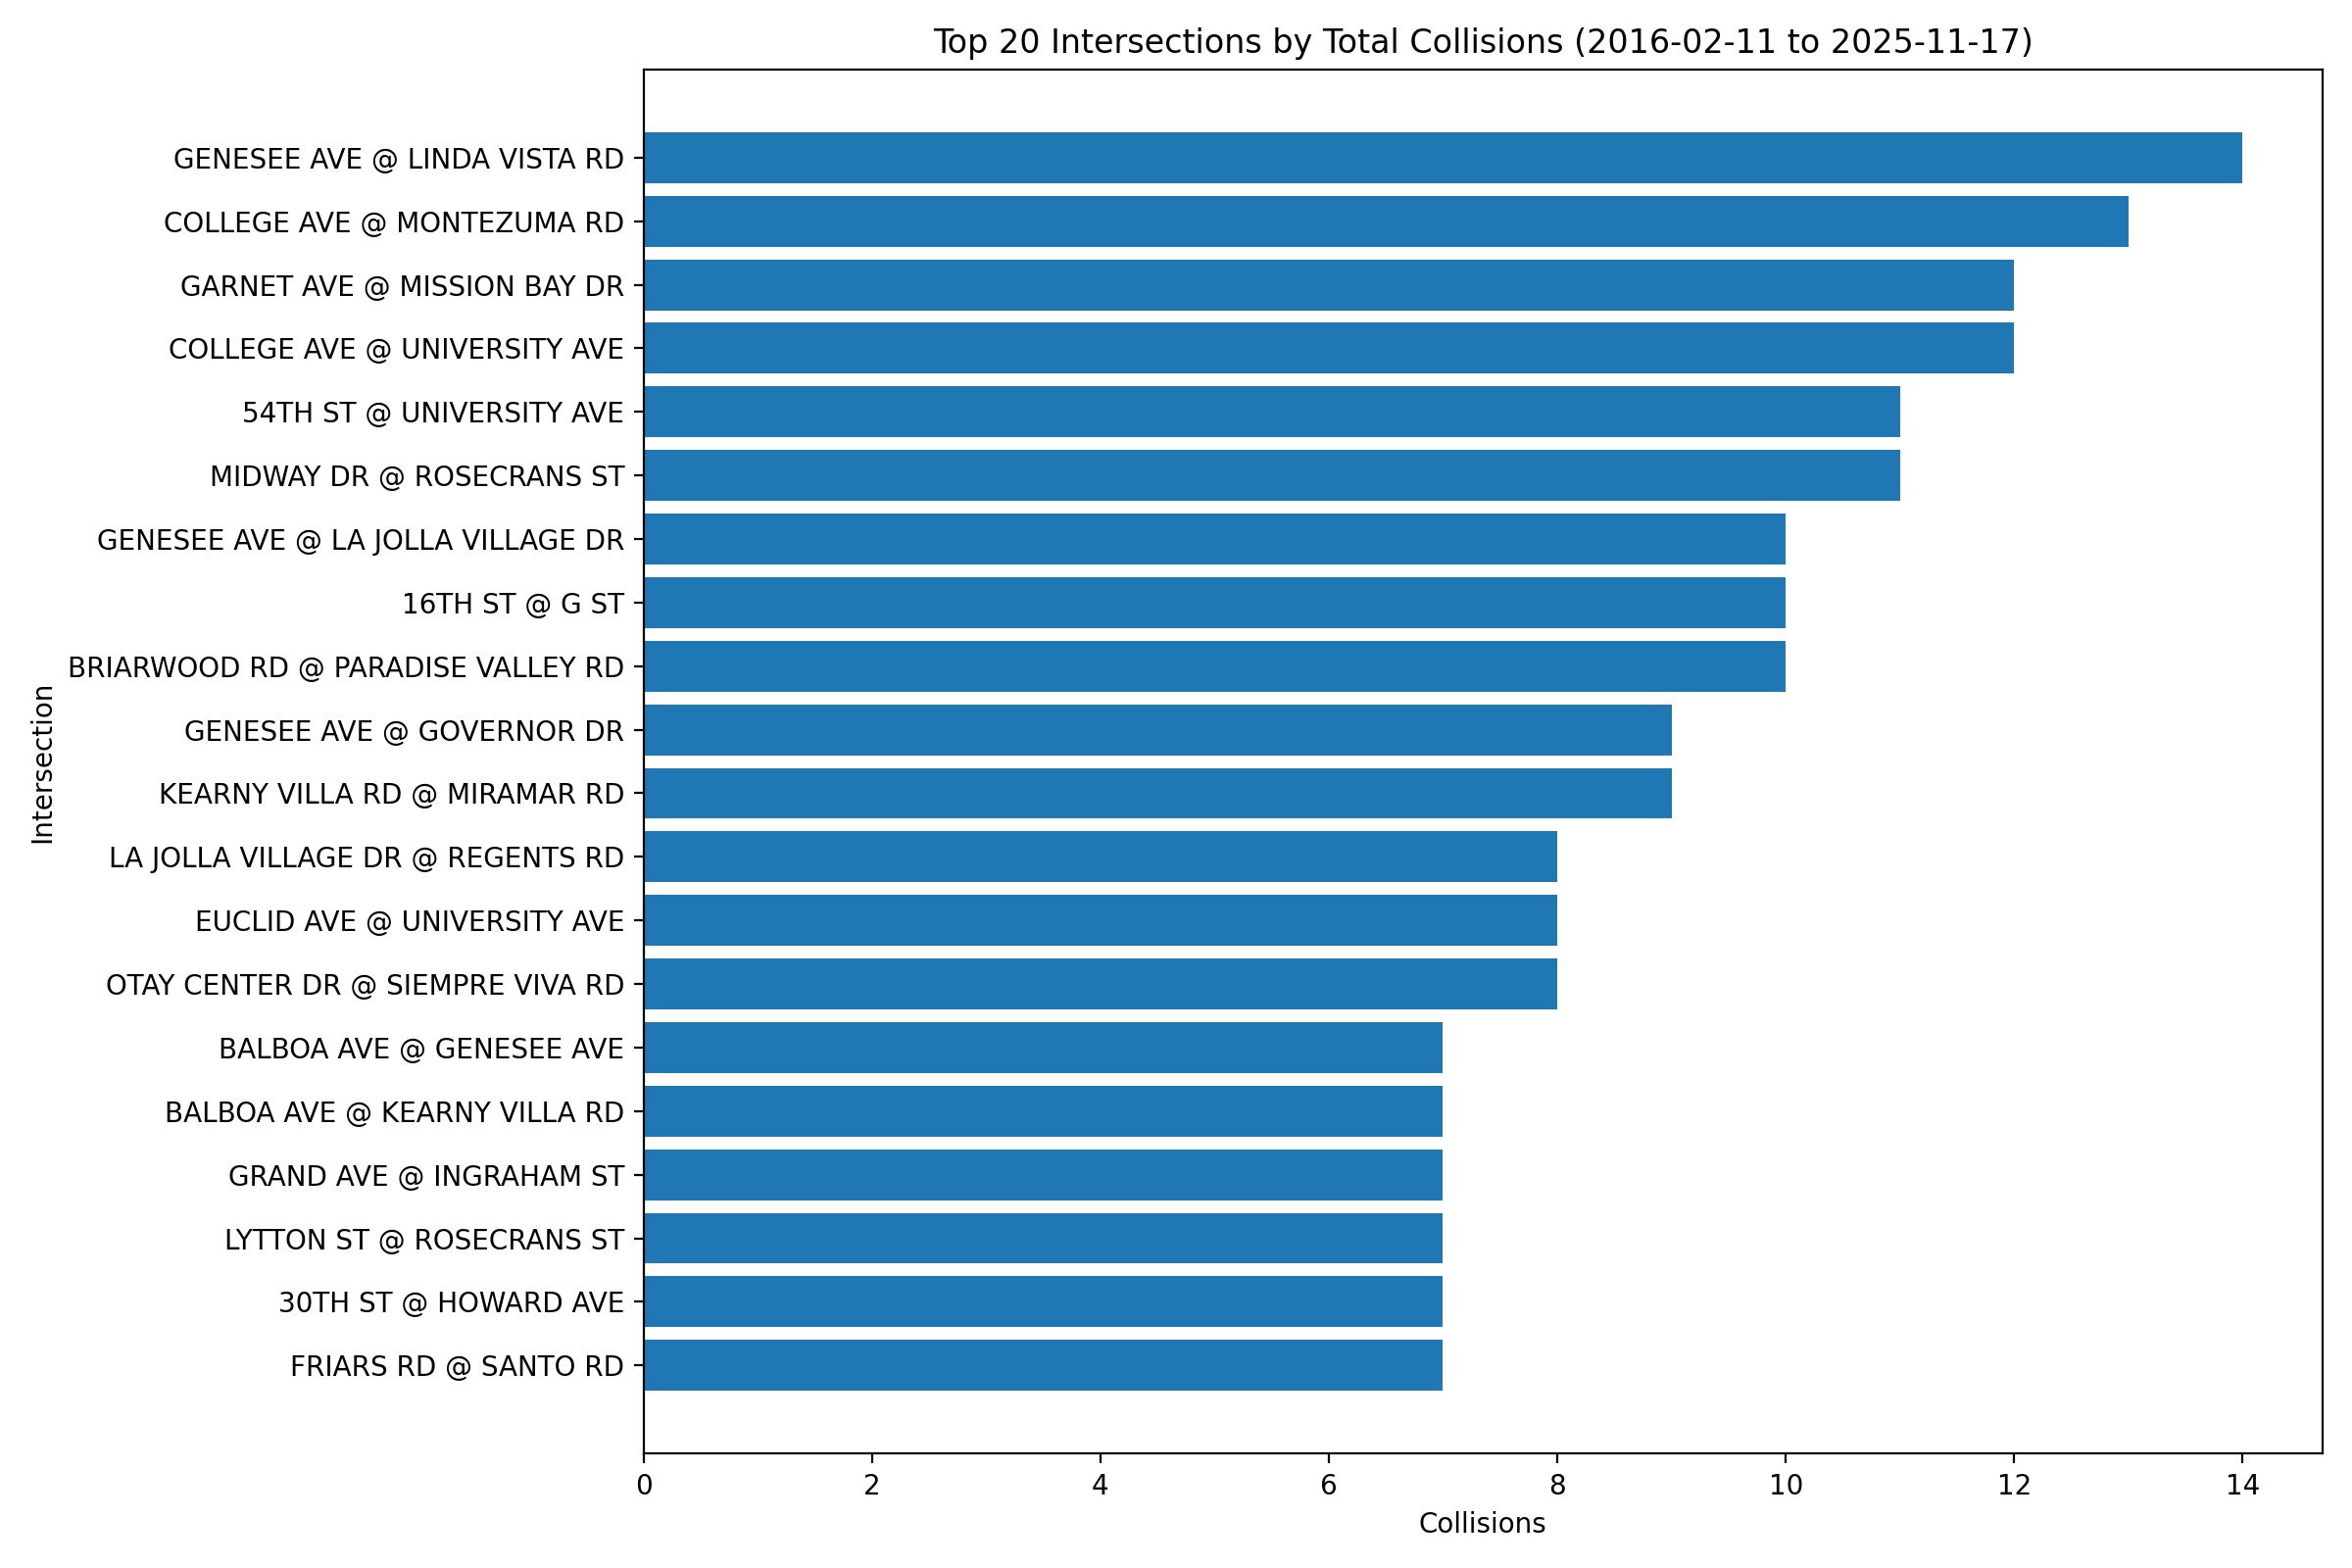

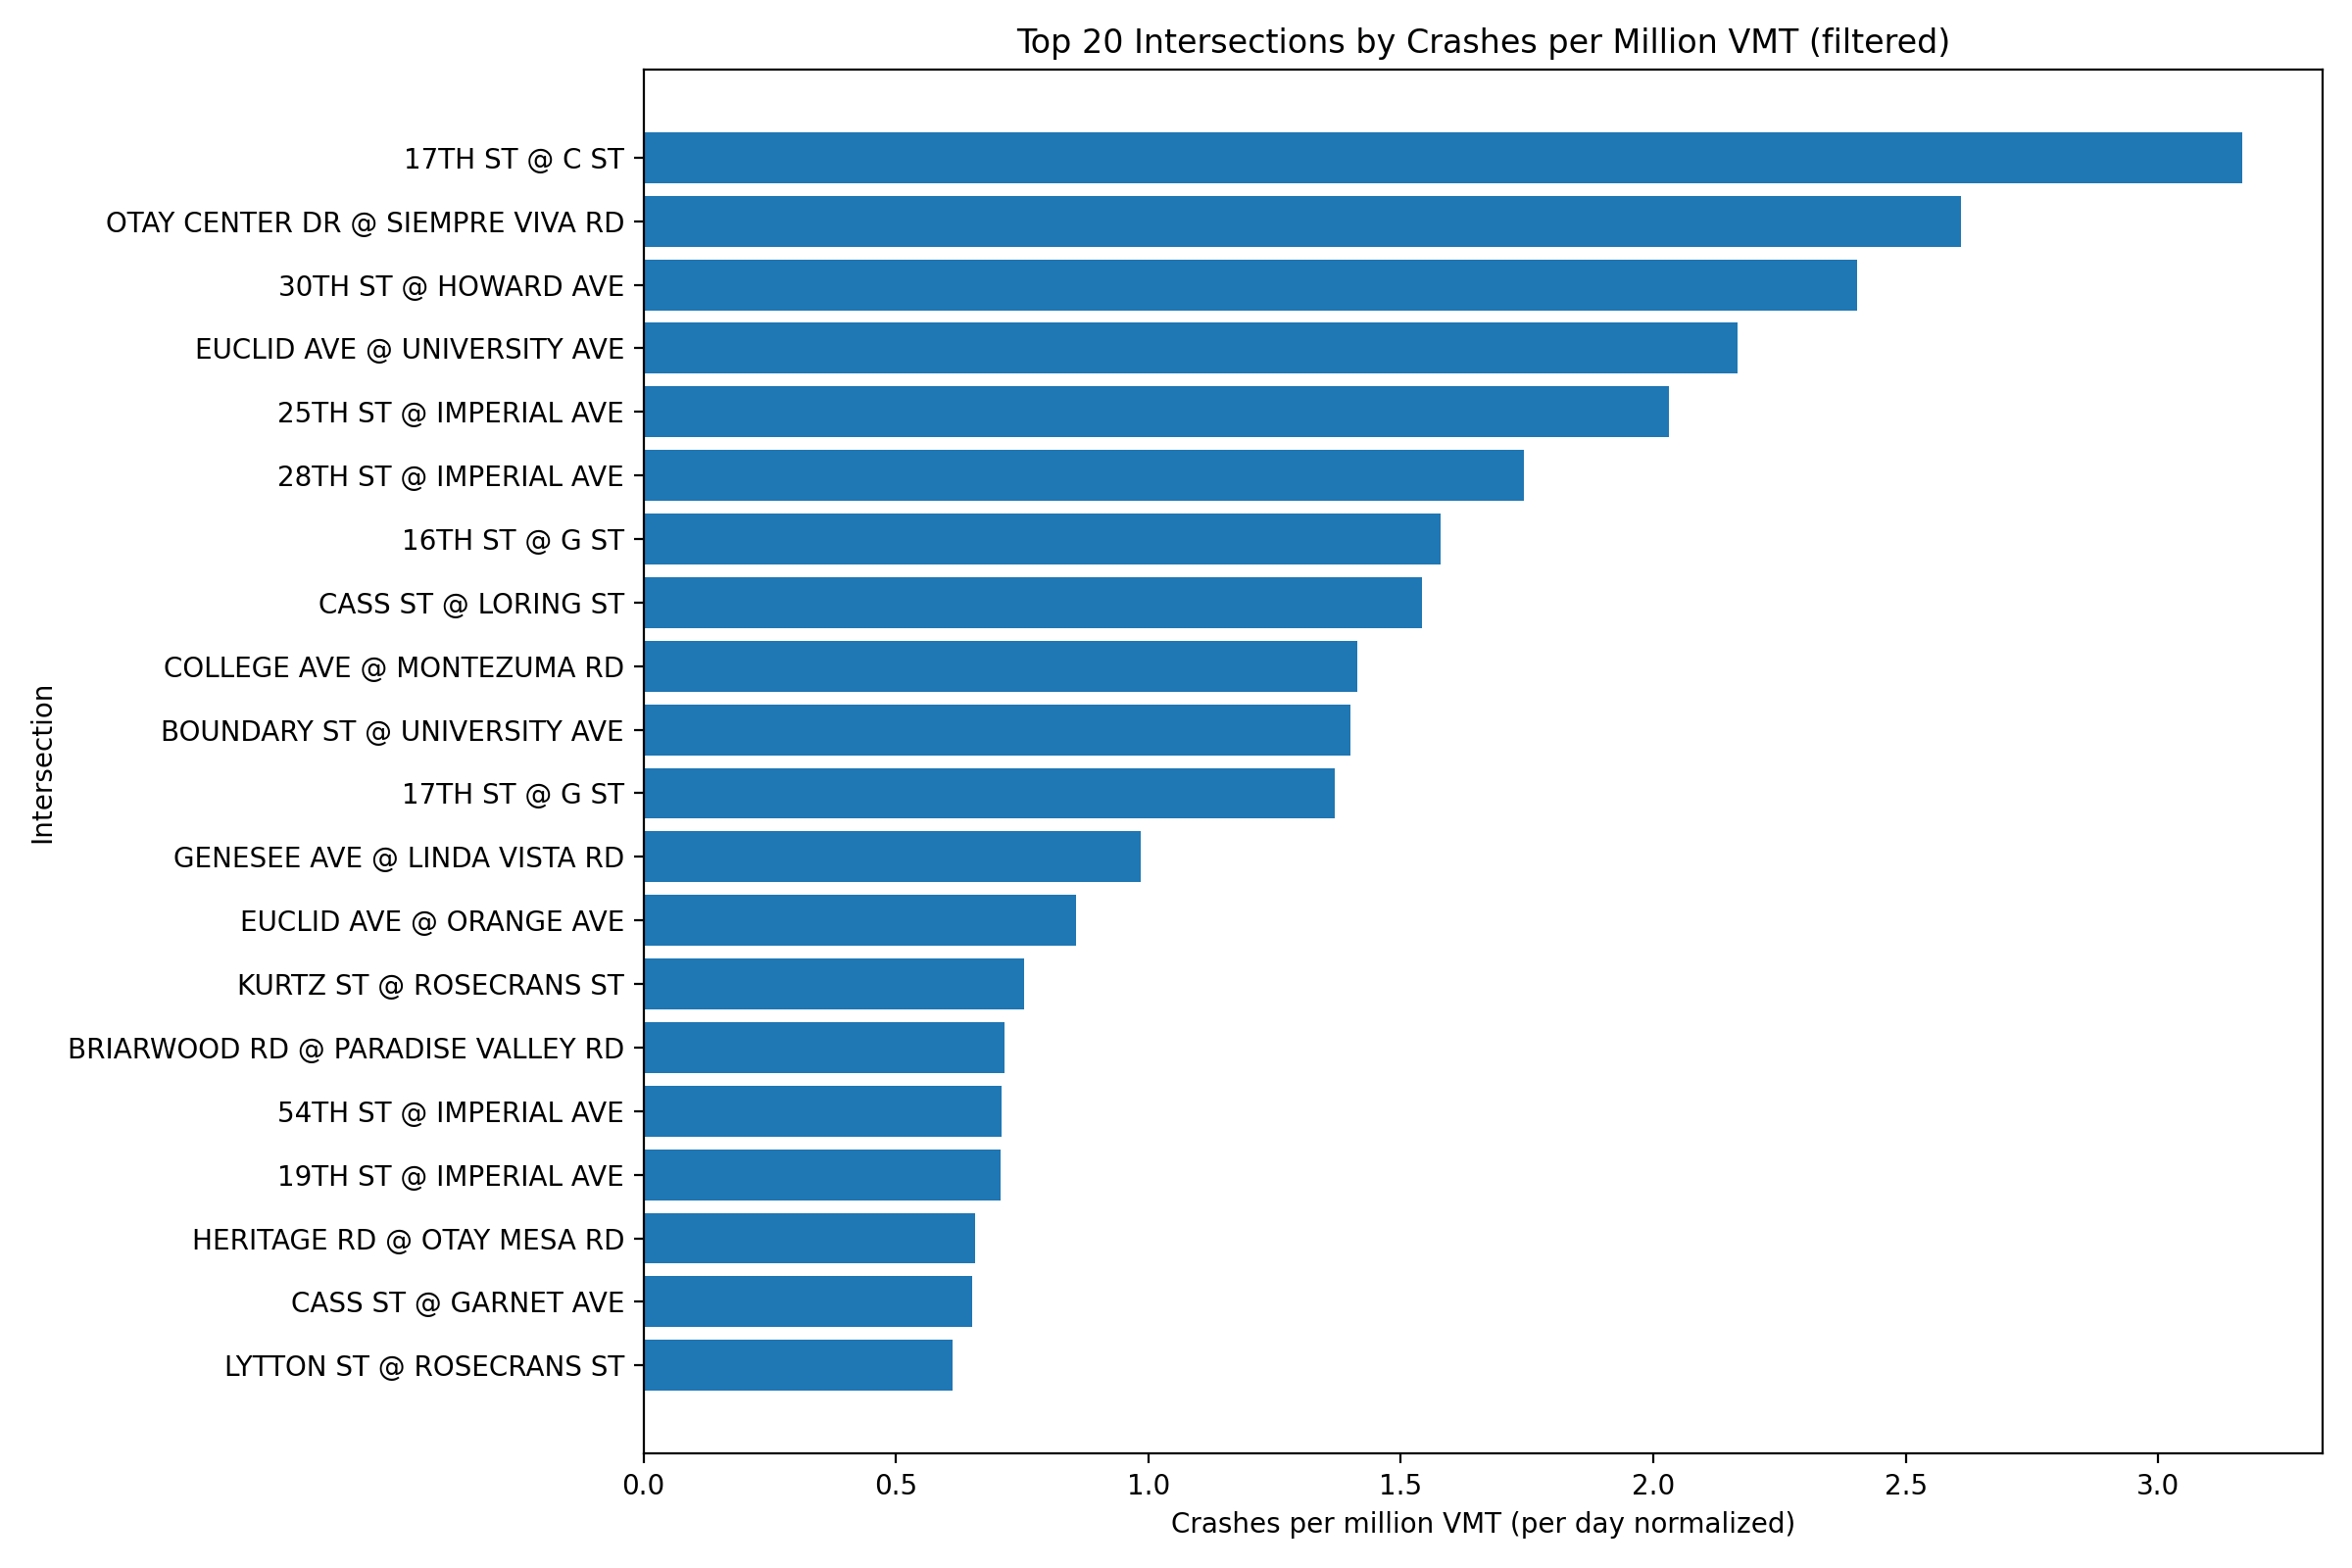

In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

'''
csvs = [
    Path("data/processed/collisions_at_intersections.csv"),
    Path("data/processed/paving_segments_with_traffic_volume.csv"),
]

for fp in csvs:
    if fp.exists():
        print(f"\n=== Preview: {fp} ===")
        display(pd.read_csv(fp).head())
    else:
        print("Missing:", fp)
'''
imgs = [
    Path("data/processed/top_intersections_by_collisions.png"),
    Path("data/processed/top_intersections_by_crash_rate_per_million_vmt.png"),
]

for img in imgs:
    if img.exists():
        display(Image(filename=str(img)))
    else:
        print("Missing:", img)